# Traffic Signal Optimization — Results Analysis
### PSO vs DE vs Hybrid · 30 runs per variant
---

## 1. Setup & Load Data

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── Load experiments.json ──────────────────────────────────────────────────
with open('./experiments.json') as f:
    data = json.load(f)

print(f'Loaded {len(data)} experiments')
for exp in data:
    print(f"  • {exp['experiment_name']:45s}  avg={exp['avg_score']:.0f}  best={exp['best_score']:.0f}  std={exp['std_score']:.0f}")

Loaded 10 experiments
  • Baseline (Constant Inertia, Global)            avg=19507  best=18226  std=612
  • Linear Inertia, Global                         avg=19463  best=18236  std=601
  • Constant Inertia, Local Topology               avg=19565  best=18434  std=579
  • Linear Inertia, Local Topology                 avg=19400  best=18410  std=547
  • Linear Inertia, Global (High c)                avg=19419  best=18300  std=492
  • Constriction Factor PSO                        avg=19432  best=18222  std=581
  • DE - rand1 Binomial Continuous                 avg=19596  best=18944  std=443
  • DE - best1 Binomial Continuous                 avg=19585  best=18539  std=455
  • DE - rand1 Exponential Continuous              avg=19512  best=17951  std=554
  • DE - rand1 Binomial Discrete                   avg=19490  best=18330  std=454


## 2. Build Summary Table

In [2]:
# ── Summary DataFrame ──────────────────────────────────────────────────────
rows = []
for exp in data:
    algo = 'PSO' if not exp['variant'].startswith('de_') else 'DE'
    rows.append({
        'Name'      : exp['experiment_name'],
        'Algorithm' : algo,
        'Best'      : exp['best_score'],
        'Average'   : round(exp['avg_score'], 1),
        'Median'    : exp['median_score'],
        'Worst'     : exp['worst_score'],
        'Std Dev'   : round(exp['std_score'], 1),
        'Avg Time(s)': round(exp['avg_runtime_s'], 2),
    })

df = pd.DataFrame(rows)
df_sorted = df.sort_values('Average')

# Style the table
df_sorted.style \
    .background_gradient(subset=['Average'], cmap='RdYlGn_r') \
    .background_gradient(subset=['Std Dev'], cmap='Blues') \
    .format({'Best': '{:.0f}', 'Average': '{:.1f}', 'Worst': '{:.0f}', 'Std Dev': '{:.1f}'}) \
    .set_caption('All Variants — Summary Statistics (sorted by Average Score)')

,Name,Algorithm,Best,Average,Median,Worst,Std Dev,Avg Time(s)
3,"Linear Inertia, Local Topology",PSO,18410,19400.2,19452.500000,20308,547.1,1.850000
4,"Linear Inertia, Global (High c)",PSO,18300,19419.4,19482.500000,20223,491.8,1.770000
5,Constriction Factor PSO,PSO,18222,19432.3,19530.000000,20279,580.9,1.810000
1,"Linear Inertia, Global",PSO,18236,19463.2,19498.500000,20599,601.2,1.870000
9,DE - rand1 Binomial Discrete,DE,18330,19489.9,19543.500000,20330,454.1,36.760000
0,"Baseline (Constant Inertia, Global)",PSO,18226,19506.9,19590.500000,20908,612.4,1.800000
8,DE - rand1 Exponential Continuous,DE,17951,19512.0,19604.500000,20625,553.8,1.980000
2,"Constant Inertia, Local Topology",PSO,18434,19565.1,19583.500000,20634,578.6,1.850000
7,DE - best1 Binomial Continuous,DE,18539,19585.4,19576.500000,20607,455.4,2.000000
6,DE - rand1 Binomial Continuous,DE,18944,19596.5,19597.000000,20384,443.4,2.250000


## 3. PSO Variants — Convergence Curves

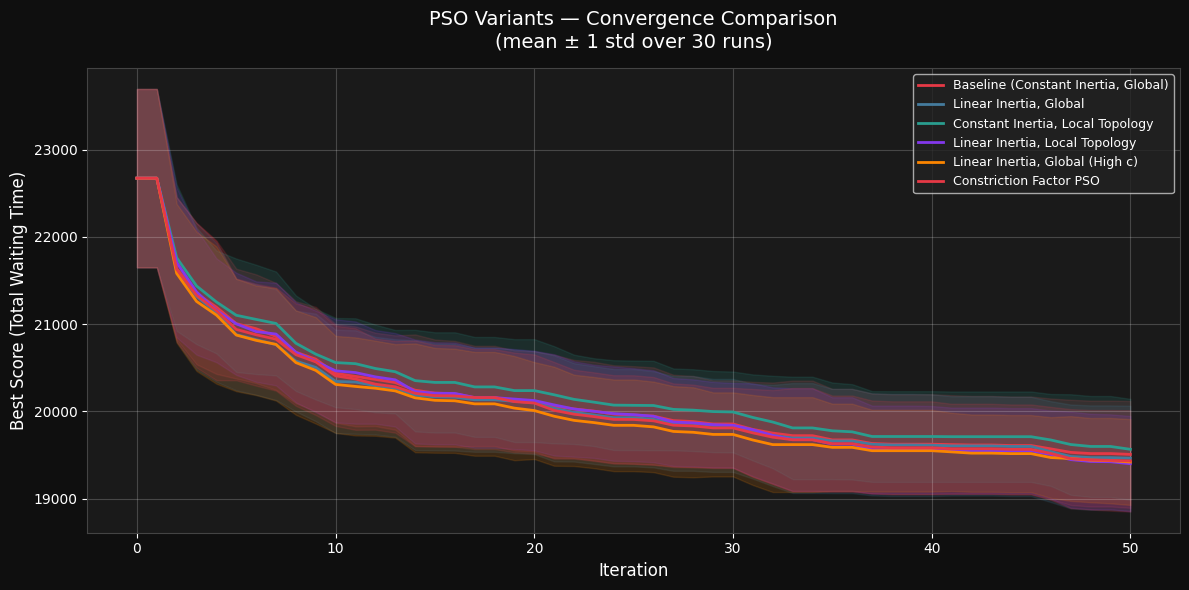

Saved → results/pso_convergence.png


In [4]:
# ── Convergence curves for PSO variants only ────────────────────────────────
pso_exps = [e for e in data if not e['variant'].startswith('de_')]

COLORS = ['#e63946','#457b9d','#2a9d8f','#8338ec','#fb8500']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

for i, exp in enumerate(pso_exps):
    histories = [run['history'] for run in exp['runs']]
    min_len   = min(len(h) for h in histories)
    arr       = np.array([h[:min_len] for h in histories])
    mean      = arr.mean(axis=0)
    std       = arr.std(axis=0)
    x         = np.arange(min_len)

    color = COLORS[i % len(COLORS)]
    ax.plot(x, mean, color=color, linewidth=2, label=exp['experiment_name'])
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel('Iteration', color='white', fontsize=12)
ax.set_ylabel('Best Score (Total Waiting Time)', color='white', fontsize=12)
ax.set_title('PSO Variants — Convergence Comparison\n(mean ± 1 std over 30 runs)', color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(alpha=0.2, color='white')
ax.legend(fontsize=9, facecolor='#222', labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.savefig('pso_convergence.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved → results/pso_convergence.png')

## 4. DE Variants — Convergence Curves

FileNotFoundError: [Errno 2] No such file or directory: 'results/de_convergence.png'

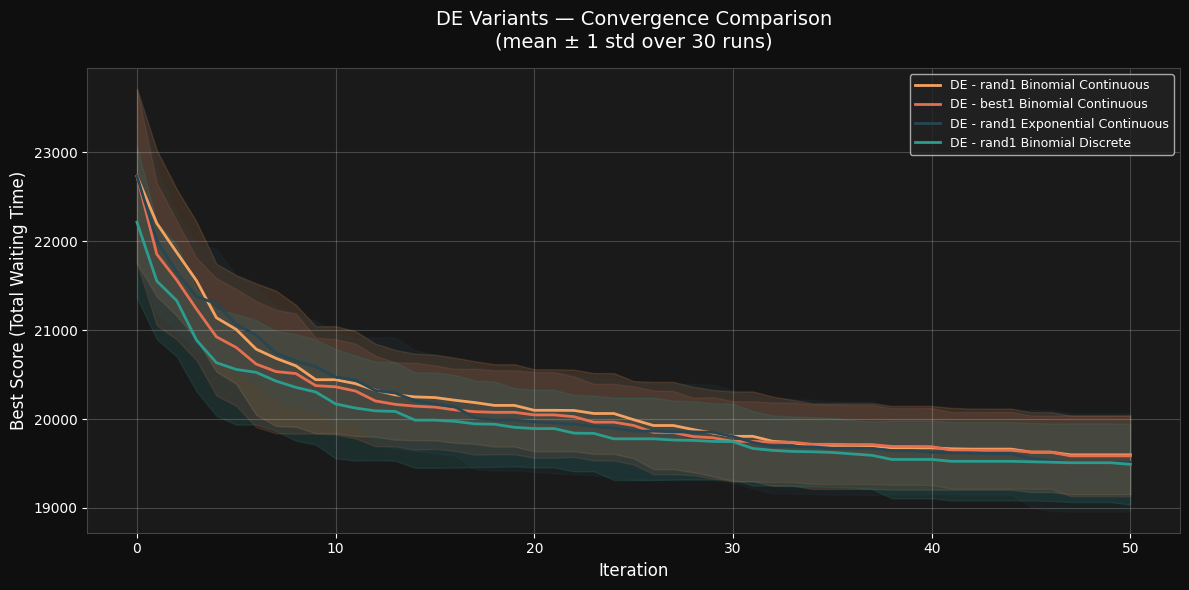

In [5]:
# ── Convergence curves for DE variants only ────────────────────────────────
de_exps = [e for e in data if e['variant'].startswith('de_')]

DE_COLORS = ['#f4a261','#e76f51','#264653','#2a9d8f']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

for i, exp in enumerate(de_exps):
    histories = [run['history'] for run in exp['runs']]
    min_len   = min(len(h) for h in histories)
    arr       = np.array([h[:min_len] for h in histories])
    mean      = arr.mean(axis=0)
    std       = arr.std(axis=0)
    x         = np.arange(min_len)

    color = DE_COLORS[i % len(DE_COLORS)]
    ax.plot(x, mean, color=color, linewidth=2, label=exp['experiment_name'])
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel('Iteration', color='white', fontsize=12)
ax.set_ylabel('Best Score (Total Waiting Time)', color='white', fontsize=12)
ax.set_title('DE Variants — Convergence Comparison\n(mean ± 1 std over 30 runs)', color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(alpha=0.2, color='white')
ax.legend(fontsize=9, facecolor='#222', labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.savefig('results/de_convergence.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved → results/de_convergence.png')

## 5. Inertia Strategy Comparison (PSO)

C:\Users\ms318\AppData\Local\Temp\ipykernel_29024\3323514150.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([constant_scores, linear_scores],


FileNotFoundError: [Errno 2] No such file or directory: 'results/inertia_comparison.png'

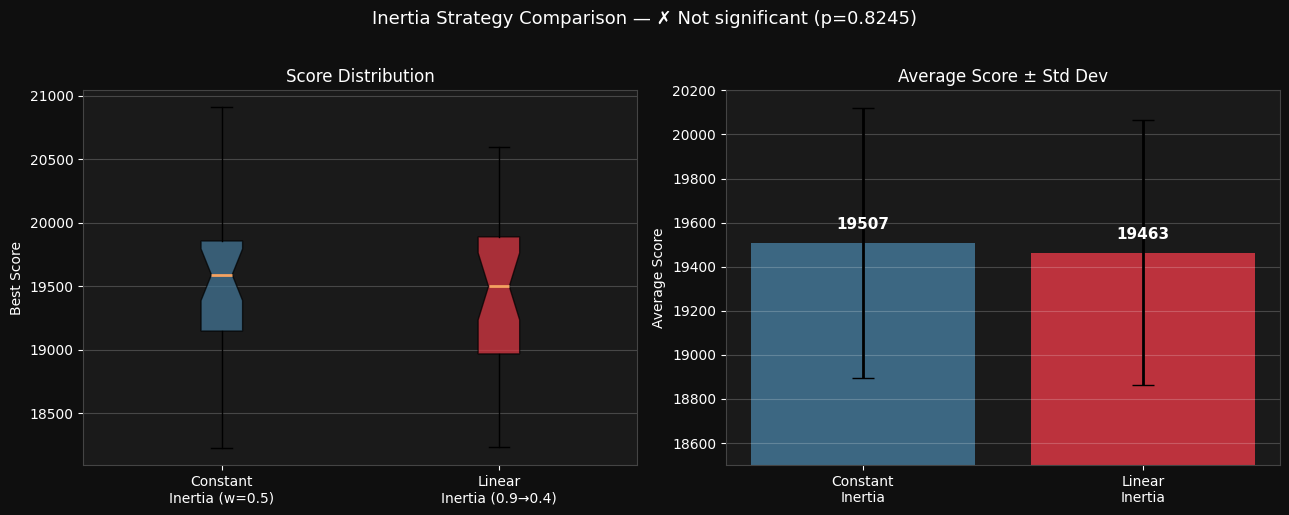

In [6]:
# ── Inertia: Constant vs Linear ────────────────────────────────────────────
constant = next(e for e in data if e['variant'] == 'constant_inertia')
linear   = next(e for e in data if e['variant'] == 'linear_inertia')

constant_scores = [r['best_score'] for r in constant['runs']]
linear_scores   = [r['best_score'] for r in linear['runs']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f0f')

# Box plot
ax = axes[0]
ax.set_facecolor('#1a1a1a')
bp = ax.boxplot([constant_scores, linear_scores],
                labels=['Constant\nInertia (w=0.5)', 'Linear\nInertia (0.9→0.4)'],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor='#457b9d', alpha=0.7),
                medianprops=dict(color='#f4a261', linewidth=2))
bp['boxes'][1].set_facecolor('#e63946')
bp['boxes'][1].set_alpha(0.7)
ax.set_title('Score Distribution', color='white', fontsize=12)
ax.set_ylabel('Best Score', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='y', alpha=0.2, color='white')

# Bar chart — avg ± std
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
names  = ['Constant\nInertia', 'Linear\nInertia']
avgs   = [constant['avg_score'], linear['avg_score']]
stds   = [constant['std_score'], linear['std_score']]
colors = ['#457b9d', '#e63946']
bars   = ax2.bar(names, avgs, yerr=stds, color=colors, alpha=0.8,
                 capsize=8, error_kw=dict(color='white', linewidth=2))
for bar, avg in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width()/2, avg + 50, f'{avg:.0f}',
             ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
ax2.set_title('Average Score ± Std Dev', color='white', fontsize=12)
ax2.set_ylabel('Average Score', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.grid(axis='y', alpha=0.2, color='white')
ax2.set_ylim(18500, 20200)

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(constant_scores, linear_scores, alternative='two-sided')
sig = '✓ Significant (p<0.05)' if p < 0.05 else '✗ Not significant'
fig.suptitle(f'Inertia Strategy Comparison — {sig} (p={p:.4f})', 
             color='white', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('results/inertia_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Mann-Whitney U: stat={stat:.1f}, p={p:.4f} → {sig}')

## 6. Topology Comparison — Global vs Local

C:\Users\ms318\AppData\Local\Temp\ipykernel_29024\3935103405.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([global_scores, local_scores],


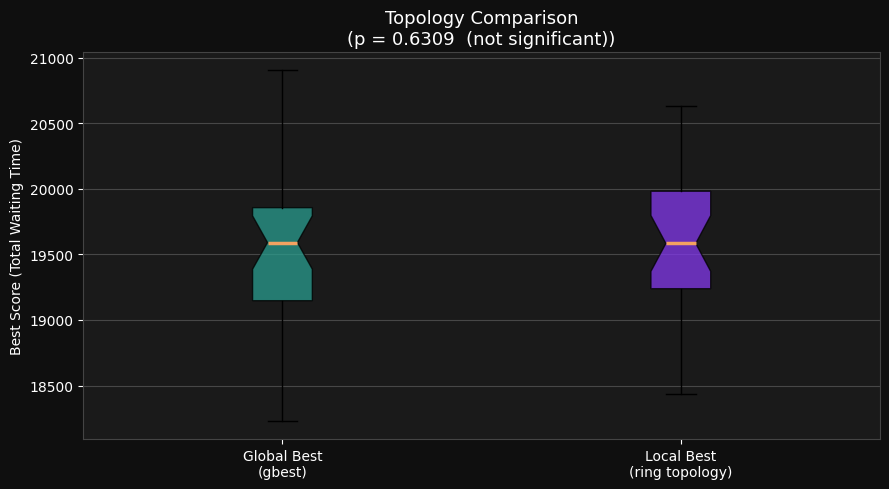

Mann-Whitney U: stat=417.0, p=0.6309


In [8]:
# ── Global Best vs Local Best topology ────────────────────────────────────
global_exp = next(e for e in data if e['variant'] == 'constant_inertia')
local_exp  = next(e for e in data if e['variant'] == 'local_topology')

global_scores = [r['best_score'] for r in global_exp['runs']]
local_scores  = [r['best_score'] for r in local_exp['runs']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

bp = ax.boxplot([global_scores, local_scores],
                labels=['Global Best\n(gbest)', 'Local Best\n(ring topology)'],
                patch_artist=True, notch=True,
                boxprops=dict(alpha=0.75),
                medianprops=dict(color='#f4a261', linewidth=2.5))
bp['boxes'][0].set_facecolor('#2a9d8f')
bp['boxes'][1].set_facecolor('#8338ec')

stat, p = stats.mannwhitneyu(global_scores, local_scores, alternative='two-sided')
sig = f'p = {p:.4f}  ({"significant" if p < 0.05 else "not significant"})'

ax.set_title(f'Topology Comparison\n({sig})', color='white', fontsize=13)
ax.set_ylabel('Best Score (Total Waiting Time)', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='y', alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('topology_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Mann-Whitney U: stat={stat:.1f}, p={p:.4f}')

## 7. PSO vs DE — Head-to-Head Comparison

C:\Users\ms318\AppData\Local\Temp\ipykernel_29024\2484095007.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pso_s, de_s],


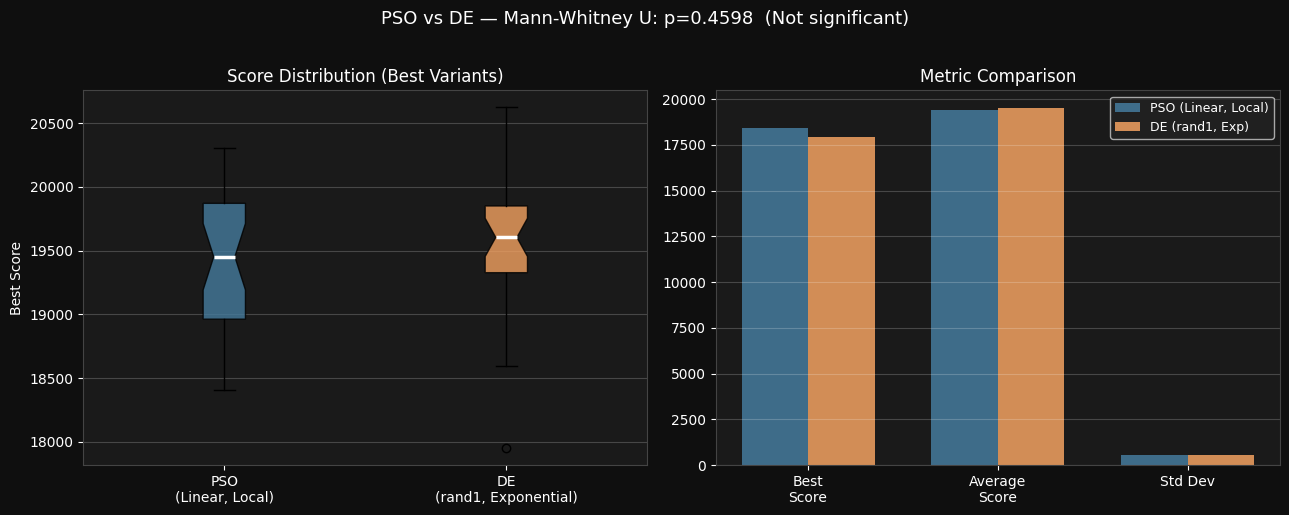

PSO avg=19400  |  DE avg=19512
PSO best=18410  |  DE best=17951


In [10]:
# ── Best PSO variant vs Best DE variant ────────────────────────────────────
# Best PSO = Linear Inertia Local Topology (avg=19400)
best_pso = next(e for e in data if e['variant'] == 'linear_local')
# Best DE  = rand1 Exponential (best score=17951)
best_de  = next(e for e in data if e['variant'] == 'de_rand1_exponential')

pso_s = [r['best_score'] for r in best_pso['runs']]
de_s  = [r['best_score'] for r in best_de['runs']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f0f')

# Box plot
ax = axes[0]
ax.set_facecolor('#1a1a1a')
bp = ax.boxplot([pso_s, de_s],
                labels=['PSO\n(Linear, Local)', 'DE\n(rand1, Exponential)'],
                patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#457b9d')
bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor('#f4a261')
bp['boxes'][1].set_alpha(0.8)
ax.set_title('Score Distribution (Best Variants)', color='white', fontsize=12)
ax.set_ylabel('Best Score', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='y', alpha=0.2, color='white')

# Metrics bar chart
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
metrics = ['Best\nScore', 'Average\nScore', 'Std Dev']
pso_vals = [best_pso['best_score'], best_pso['avg_score'], best_pso['std_score']]
de_vals  = [best_de['best_score'],  best_de['avg_score'],  best_de['std_score']]
x = np.arange(len(metrics))
w = 0.35
ax2.bar(x - w/2, pso_vals, w, label='PSO (Linear, Local)', color='#457b9d', alpha=0.85)
ax2.bar(x + w/2, de_vals,  w, label='DE (rand1, Exp)',     color='#f4a261', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, color='white')
ax2.set_title('Metric Comparison', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.grid(axis='y', alpha=0.2, color='white')
ax2.legend(facecolor='#222', labelcolor='white', fontsize=9)

# Statistical test
stat, p = stats.mannwhitneyu(pso_s, de_s, alternative='two-sided')
fig.suptitle(f'PSO vs DE — Mann-Whitney U: p={p:.4f}  ({"Significant" if p < 0.05 else "Not significant"})',
             color='white', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('pso_vs_de.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'PSO avg={best_pso["avg_score"]:.0f}  |  DE avg={best_de["avg_score"]:.0f}')
print(f'PSO best={best_pso["best_score"]:.0f}  |  DE best={best_de["best_score"]:.0f}')

# 8. All algorithms: PSO best vs DE best vs Hybrid best

In [ ]:
# ── All algorithms: PSO best vs DE best vs Hybrid best ─────────────────────
best_pso    = min((e for e in data if not e['variant'].startswith('de_') 
                   and not e['variant'].startswith('hybrid_')), 
                  key=lambda x: x['avg_score'])
best_de     = min((e for e in data if e['variant'].startswith('de_')), 
                  key=lambda x: x['avg_score'])
best_hybrid = min((e for e in data if e['variant'].startswith('hybrid_')), 
                  key=lambda x: x['avg_score'])

pso_s    = [r['best_score'] for r in best_pso['runs']]
de_s     = [r['best_score'] for r in best_de['runs']]
hybrid_s = [r['best_score'] for r in best_hybrid['runs']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f0f')

# Box plot
ax = axes[0]
ax.set_facecolor('#1a1a1a')
bp = ax.boxplot([pso_s, de_s, hybrid_s],
                labels=['PSO', 'DE', 'Hybrid\nPSO-DE'],
                patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#457b9d')
bp['boxes'][1].set_facecolor('#f4a261')
bp['boxes'][2].set_facecolor('#2a9d8f')
for box in bp['boxes']:
    box.set_alpha(0.8)
ax.set_title('Score Distribution', color='white', fontsize=12)
ax.set_ylabel('Best Score', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='y', alpha=0.2, color='white')

# Bar chart
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
algos  = ['PSO', 'DE', 'Hybrid']
avgs   = [best_pso['avg_score'], best_de['avg_score'], best_hybrid['avg_score']]
bests  = [best_pso['best_score'], best_de['best_score'], best_hybrid['best_score']]
stds   = [best_pso['std_score'], best_de['std_score'], best_hybrid['std_score']]
colors = ['#457b9d', '#f4a261', '#2a9d8f']
x = np.arange(len(algos))
w = 0.35
ax2.bar(x - w/2, avgs,  w, label='Average', color=colors, alpha=0.85, yerr=stds,
        capsize=8, error_kw=dict(color='white', linewidth=1.5))
ax2.bar(x + w/2, bests, w, label='Best',    color=colors, alpha=0.5)
for i, (avg, best) in enumerate(zip(avgs, bests)):
    ax2.text(i - w/2, avg + 50, f'{avg:.0f}', ha='center', color='white', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, best + 50, f'{best:.0f}', ha='center', color='white', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(algos, color='white')
ax2.set_title('Avg & Best Score per Algorithm', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.grid(axis='y', alpha=0.2, color='white')
ax2.legend(facecolor='#222', labelcolor='white', fontsize=9)

# winner
winner = algos[np.argmin(avgs)]
fig.suptitle(f'PSO vs DE vs Hybrid — Winner: {winner}', color='white', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('results/pso_de_hybrid_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f'PSO    avg={best_pso["avg_score"]:.0f}  best={best_pso["best_score"]:.0f}')
print(f'DE     avg={best_de["avg_score"]:.0f}  best={best_de["best_score"]:.0f}')
print(f'Hybrid avg={best_hybrid["avg_score"]:.0f}  best={best_hybrid["best_score"]:.0f}')

## 9. All Variants — Bar Chart (Average Score)

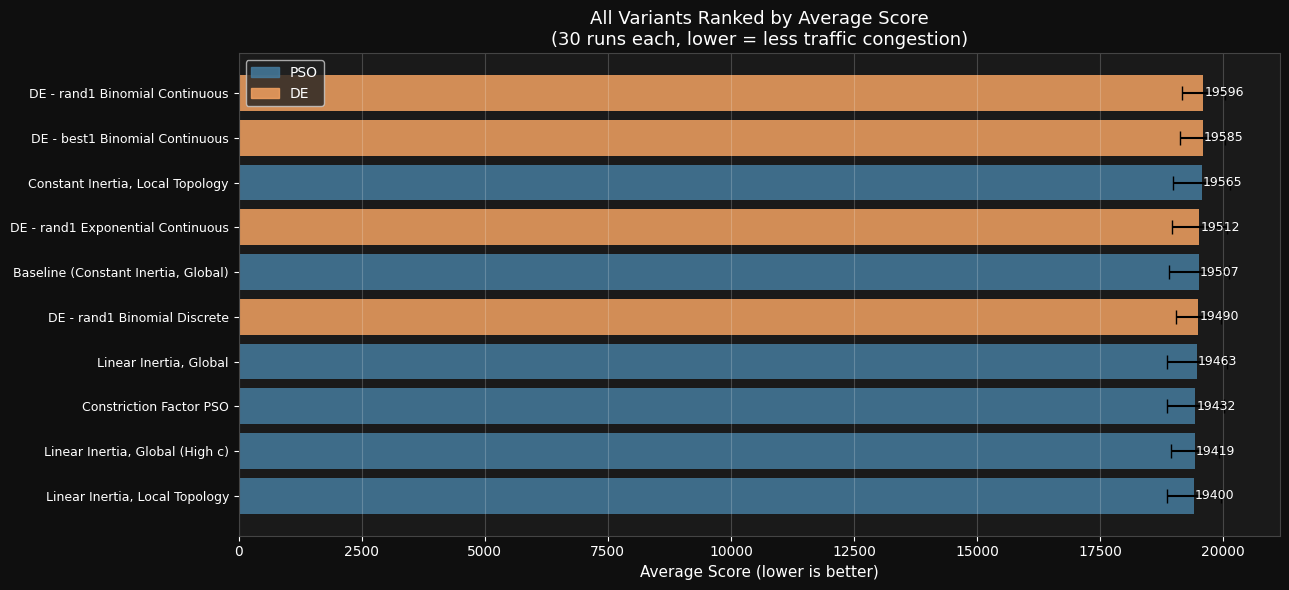

In [12]:
# ── All variants ranked by average score ──────────────────────────────────
names  = [e['experiment_name'] for e in data]
avgs   = [e['avg_score']       for e in data]
stds   = [e['std_score']       for e in data]
algos  = ['PSO' if not e['variant'].startswith('de_') else 'DE' for e in data]

# sort by avg
order  = np.argsort(avgs)
names  = [names[i] for i in order]
avgs   = [avgs[i]  for i in order]
stds   = [stds[i]  for i in order]
algos  = [algos[i] for i in order]

colors = ['#457b9d' if a == 'PSO' else '#f4a261' for a in algos]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

y = np.arange(len(names))
bars = ax.barh(y, avgs, xerr=stds, color=colors, alpha=0.85,
               capsize=5, error_kw=dict(color='white', linewidth=1.5))

for bar, avg in zip(bars, avgs):
    ax.text(avg + 20, bar.get_y() + bar.get_height()/2,
            f'{avg:.0f}', va='center', color='white', fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(names, color='white', fontsize=9)
ax.set_xlabel('Average Score (lower is better)', color='white', fontsize=11)
ax.set_title('All Variants Ranked by Average Score\n(30 runs each, lower = less traffic congestion)',
             color='white', fontsize=13)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='x', alpha=0.2, color='white')

pso_patch = mpatches.Patch(color='#457b9d', alpha=0.85, label='PSO')
de_patch  = mpatches.Patch(color='#f4a261', alpha=0.85, label='DE')
ax.legend(handles=[pso_patch, de_patch], facecolor='#222', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('all_variants_ranked.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 10. Statistical Summary — Report-Ready Table

In [15]:
# ── Full statistical table ─────────────────────────────────────────────────
print('=' * 100)
print(f'{"Variant":<45} {"Algo":>5} {"Best":>8} {"Avg":>8} {"Median":>8} {"Worst":>8} {"Std":>7} {"Time(s)":>8}')
print('=' * 100)

for exp in sorted(data, key=lambda x: x['avg_score']):
    algo = 'PSO' if not exp['variant'].startswith('de_') else 'DE '
    print(f"{exp['experiment_name']:<45} {algo:>5} "
          f"{exp['best_score']:>8.0f} "
          f"{exp['avg_score']:>8.0f} "
          f"{exp['median_score']:>8.0f} "
          f"{exp['worst_score']:>8.0f} "
          f"{exp['std_score']:>7.0f} "
          f"{exp['avg_runtime_s']:>8.2f}")

print('=' * 100)
print()
print('KEY FINDINGS:')
best_avg = min(data, key=lambda x: x['avg_score'])
best_abs = min(data, key=lambda x: x['best_score'])
print(f'  • Best average score : {best_avg["experiment_name"]} → {best_avg["avg_score"]:.0f}')
print(f'  • Best single run    : {best_abs["experiment_name"]} → {best_abs["best_score"]:.0f}')

pso_avgs = [e['avg_score'] for e in data if not e['variant'].startswith('de_')]
de_avgs  = [e['avg_score'] for e in data if e['variant'].startswith('de_')]
print(f'  • PSO mean-of-avgs   : {np.mean(pso_avgs):.0f}')
print(f'  • DE  mean-of-avgs   : {np.mean(de_avgs):.0f}')
winner = 'PSO' if np.mean(pso_avgs) < np.mean(de_avgs) else 'DE'
print(f'  • Overall winner     : {winner}')

Variant                                        Algo     Best      Avg   Median    Worst     Std  Time(s)
Linear Inertia, Local Topology                  PSO    18410    19400    19452    20308     547     1.85
Linear Inertia, Global (High c)                 PSO    18300    19419    19482    20223     492     1.77
Constriction Factor PSO                         PSO    18222    19432    19530    20279     581     1.81
Linear Inertia, Global                          PSO    18236    19463    19498    20599     601     1.87
DE - rand1 Binomial Discrete                    DE     18330    19490    19544    20330     454    36.76
Baseline (Constant Inertia, Global)             PSO    18226    19507    19590    20908     612     1.80
DE - rand1 Exponential Continuous               DE     17951    19512    19604    20625     554     1.98
Constant Inertia, Local Topology                PSO    18434    19565    19584    20634     579     1.85
DE - best1 Binomial Continuous                  DE     

## 11. Before vs After Optimization

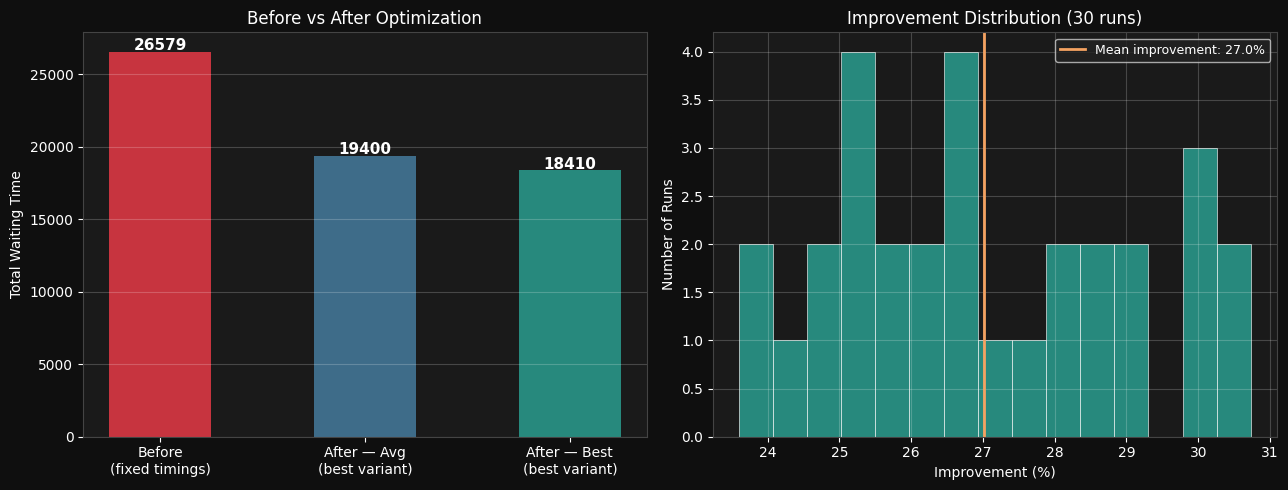

Average improvement: 27.0%
Best improvement   : 30.7%


In [14]:
# ── Before (unoptimized) vs After (best variant) ───────────────────────────
BASELINE_SCORE = 26579   # from main.py output: timings=[20,20,20]

best_exp    = min(data, key=lambda x: x['avg_score'])
best_scores = [r['best_score'] for r in best_exp['runs']]
improvement = [(BASELINE_SCORE - s) / BASELINE_SCORE * 100 for s in best_scores]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f0f')

# Bar: before vs after
ax = axes[0]
ax.set_facecolor('#1a1a1a')
vals   = [BASELINE_SCORE, best_exp['avg_score'], best_exp['best_score']]
labels = ['Before\n(fixed timings)', 'After — Avg\n(best variant)', 'After — Best\n(best variant)']
bar_colors = ['#e63946', '#457b9d', '#2a9d8f']
bars = ax.bar(labels, vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'{val:.0f}', ha='center', color='white', fontweight='bold', fontsize=11)
ax.set_ylabel('Total Waiting Time', color='white')
ax.set_title('Before vs After Optimization', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.grid(axis='y', alpha=0.2, color='white')

# Improvement distribution
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
ax2.hist(improvement, bins=15, color='#2a9d8f', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.axvline(np.mean(improvement), color='#f4a261', linewidth=2,
            label=f'Mean improvement: {np.mean(improvement):.1f}%')
ax2.set_xlabel('Improvement (%)', color='white')
ax2.set_ylabel('Number of Runs', color='white')
ax2.set_title('Improvement Distribution (30 runs)', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.grid(alpha=0.2, color='white')
ax2.legend(facecolor='#222', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('before_after.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Average improvement: {np.mean(improvement):.1f}%')
print(f'Best improvement   : {max(improvement):.1f}%')